# Benchmarking with networkx

This notebook is an example of benchmarking community detection algorithms using ABCD with networkx. Since networkx is quite slow without configuring a backend (which is beyond this notebook), we'll keep the size of the ABCD graph quite small. If you want to see how the algorithms perform on larger graphs, check out [benchmarking with igraph.](benchmark_igraph.ipynb)

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import partition_networkx
from sklearn.metrics import adjusted_rand_score as ari
from tqdm import tqdm

from abcd_graph import ABCD

In [2]:
# Assign ecg as networkx community method
nx.algorithms.community.ecg_community = partition_networkx.community_ecg

In [3]:
algs = [
    "louvain_communities",
    "label_propagation_communities",
    "ecg_community",
]

## Performance

First lets test how well each algorithms can detect the ground truth communities subject to increasing amount of noise in the graph. To evaluate the similarity between the ground truth partition, we'll use the adjusted rand index (ARI) and a graph aware adjustment (GARI).

In [4]:
n = 1000
xis = np.linspace(0.1, 0.7, 13)
reps = 10

aris = np.empty((len(algs), len(xis), reps))
garis = np.empty_like(aris)

abcd = ABCD(n)

with tqdm(total=len(xis) * reps * len(algs)) as pbar:
    for j, xi in enumerate(xis):
        abcd.xi = xi
        for k in range(reps):
            sample = abcd.sample()
            sample_graph = sample.to_networkx()
            sample_coms = {
                node: com
                for com, nodes in sample.community_dict.items()
                for node in nodes
            }

            for i, alg in enumerate(algs):
                predict = getattr(nx.algorithms.community, alg)(sample_graph)
                if isinstance(predict, tuple):
                    predict = predict.partition
                else:
                    predict = {
                        node: com for com, nodes in enumerate(predict) for node in nodes
                    }
                aris[i, j, k] = ari(
                    [sample_coms[i] for i in range(n)],
                    [predict[i] for i in range(n)],
                )
                garis[i, j, k] = sample_graph.gam(sample_coms, predict)
                pbar.update()

100%|██████████| 390/390 [04:39<00:00,  1.39it/s]


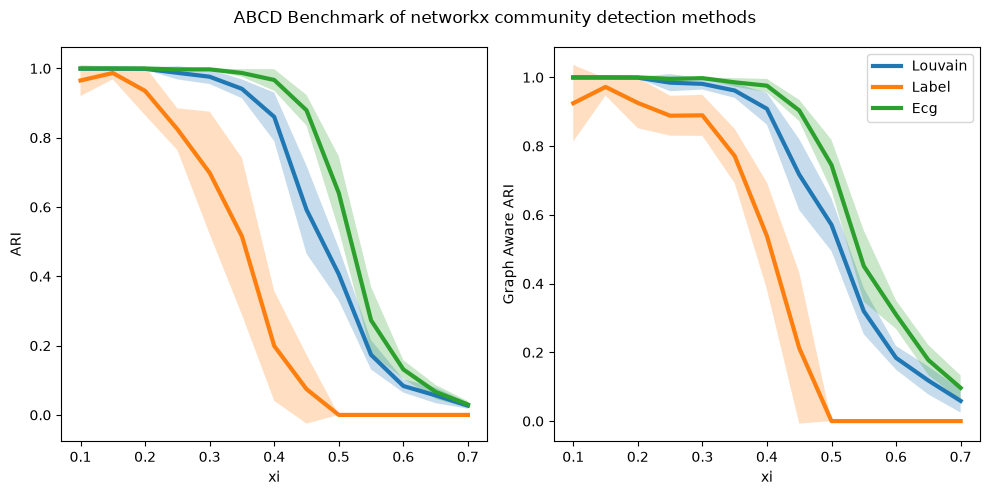

In [5]:
ari_means = np.mean(aris, axis=2)
ari_stds = np.std(aris, axis=2)
gari_means = np.mean(garis, axis=2)
gari_stds = np.std(garis, axis=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for i, alg in enumerate(algs):
    name = alg.split("_")[0]
    axs[0].plot(xis, ari_means[i], lw=3, label=name.capitalize())
    axs[0].fill_between(
        xis, ari_means[i] - ari_stds[i], ari_means[i] + ari_stds[i], alpha=0.25
    )

    axs[1].plot(xis, gari_means[i], lw=3, label=name.capitalize())
    axs[1].fill_between(
        xis, gari_means[i] - gari_stds[i], gari_means[i] + gari_stds[i], alpha=0.25
    )
axs[1].legend()

axs[0].set_xlabel("xi")
axs[0].set_ylabel("ARI")

axs[1].set_ylabel("Graph Aware ARI")
axs[1].set_xlabel("xi")

fig.suptitle("ABCD Benchmark of networkx community detection methods")
fig.tight_layout()

## Time

We can also use ABCD to test how each algorithm scales.

In [6]:
ns = np.linspace(200, 1000, 9, dtype="int64")
reps = 10

times = np.empty((len(algs), len(ns), reps))

abcd = ABCD(1000)

with tqdm(total=len(ns) * reps * len(algs)) as pbar:
    for j, n in enumerate(ns):
        abcd.n = n
        for k in range(reps):
            sample = abcd.sample()
            sample_graph = sample.to_networkx()

            for i, alg in enumerate(algs):
                start = perf_counter()
                predict = getattr(nx.algorithms.community, alg)(sample_graph)
                end = perf_counter()
                times[i, j, k] = end - start
                pbar.update()

100%|██████████| 270/270 [01:12<00:00,  3.74it/s]


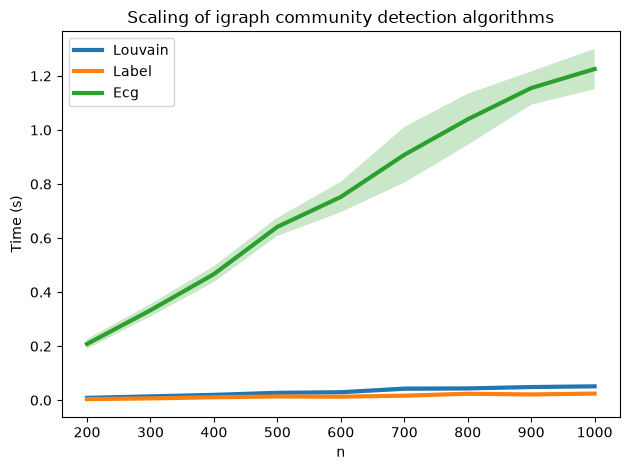

In [7]:
time_means = np.mean(times, axis=2)
time_stds = np.std(times, axis=2)

for i, alg in enumerate(algs):
    name = alg.split("_")[0]
    if name == "multilevel":
        name = "louvain"
    plt.plot(ns, time_means[i], lw=3, label=name.capitalize())
    plt.fill_between(
        ns, time_means[i] - time_stds[i], time_means[i] + time_stds[i], alpha=0.25
    )

plt.legend()
plt.title("Scaling of igraph community detection algorithms")
plt.xlabel("n")
plt.ylabel("Time (s)")
plt.tight_layout()

## References

Louvain
- [Vincent D Blondel, Jean-Loup Guillaume, Renaud Lambiotte and Etienne Lefebvre. Fast unfolding of communities in large networks. Journal of Statistical Mechanics: Theory and Experiment, P10008 (2008) doi: 10.1088/1742-5468/2008/10/P10008](https://doi.org/10.1088/1742-5468/2008/10/P10008)

ECG
- [Valérie Poulin & François Théberge. Ensemble clustering for graphs: comparisons and applications. Applied Network Science, 4:51 (2019) doi: 10.1007/s41109-019-0162-z](https://doi.org/10.1007/s41109-019-0162-z)

Label Propagation
- [Usha Nandini Raghavan, Réka Albert, and Soundar Kumara. Near linear time algorithm to detect community structures in large-scale networks. Physical Review E, 76:036106 (2007) doi: 10.1103/PhysRevE.76.036106](https://doi.org/10.1103/PhysRevE.76.036106)

ARI
- [Lawrence Hubert and Phipps Arabie. Comparing partitions.  Journal of Classification , 2:193–218 (1985) doi: 10.1007/BF01908075](https://doi.org/10.1007/BF01908075)

Graph Aware ARI
- [Valérie Poulin and François Théberge. Comparing Graph Clusterings: Set Partition Measures vs. Graph-Aware Measures. IEEE Transactions on Pattern Analysis and Machine Intelligence, 43(6):2127 - 2132 (2021) doi: 10.1109/TPAMI.2020.3009862](https://doi.org/10.1109/TPAMI.2020.3009862)